# Setup & Imports 

In [23]:
import os
import operator
import time 
import requests

from google import genai
from google.genai import types
from typing import TypedDict, Annotated, List, Literal, Optional
from pydantic import BaseModel, Field, field_validator, model_validator
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, SystemMessage
from pathlib import Path
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langchain_google_genai import ChatGoogleGenerativeAI
# Tavily Search is the Search Engine for Ai-Agents.
from langchain_community.tools.tavily_search import TavilySearchResults

In [31]:
load_dotenv()

True

# LLM Configuration

In [ ]:
llm = ChatGroq( 
    model = 'llama-3.3-70b-versatile',
    temperature= 0.7,
    groq_api_key= os.getenv('GROQ_API_KEY')
)

# Pydantic Model & Schemas

In [4]:
class Task(BaseModel):
    id : int
    title : str
    description : str = Field(description= 'What to cover tough.')
    goal : str = Field(description= 'One sentence describing what the reader should be able to understand after this.')
    target_words : int = Field(description= 'Max Length of words for this section is (400-600)')    
    bullets : List[str] = Field(
        description= 'Between 5-8 concrete, non-overlapping points to cover this section.'
    )
    require_research : bool =  False
    require_citation : bool = False
    require_code : bool = False

In [5]:
class Plan(BaseModel):
    blog_title : str
    audience : str = Field(description= 'What kind of people can relate to this blog.')
    tone : str = Field(description= 'What quality of language the blog contain(proffesional, fluent etc)')
    tasks : List[Task]
    blog_kind : Literal['explainer', 'tutorial', 'comparison', 'system_design'] = 'explainer'
    constraints : List[str] = Field(default_factory= list)

    @field_validator('blog_kind', mode='before')
    @classmethod
    def fix_blog_kind(cls, v):
        allowed = ['explainer', 'tutorial', 'comparison', 'system_design']
        if isinstance(v, str):
            for a in allowed:
                if a in v.lower():
                    return a
        return 'explainer'

    @field_validator('constraints', mode='before')
    @classmethod
    def fix_constraints(cls, v):
        if not v:
            return []
        if isinstance(v, dict):
            v = list(v.values())
        if isinstance(v, list):
            result = []
            for item in v:
                if isinstance(item, str):
                    result.append(item)
                elif isinstance(item, (list, dict)):
                    pass
            return result
        return []

In [6]:
class Evidence(BaseModel):
    title : str
    url : str
    snippet : Optional[str] = None
    source : Optional[str] = None
    published_at : Optional[str] = None


In [7]:
class EvidencePack(BaseModel):
    evidence : List[Evidence] = Field(default_factory= list)

In [8]:
class RouterDecision(BaseModel):
    needs_research : bool = False
    research_method : Literal['open_book', 'close_book', 'hybrid']
    queries : List[str] = Field(default_factory= list)

In [9]:
class ImageSpecs(BaseModel):
    placeholder: str = Field(description='e.g[[IMAGE_1]]')
    filename: str = Field(description='demo_flow.png or demo_flow.jpg')
    alt: str
    caption: str
    prompt: str = Field(description='The prompt send to the image model.')
    size: Literal['1024x1024', '1024x1536', '1536x1024'] = '1024x1024'
    quality: Literal['low', 'medium', 'high'] = 'medium'
# These validators act as safety net against invalid values send by LLM.
    @field_validator('size', mode='before') #'before' validator runs before Pydantic does its own type checking, so values like "large" or None won't crash the model 
    @classmethod
    # 'cls' is class itself(use before class obj been created.) 'v' is value
    def fix_size(cls, v):
        allowed = ['1024x1024', '1024x1536', '1536x1024']
        if v in allowed:
            return v
        return '1024x1024'

    @field_validator('quality', mode='before')
    @classmethod
    def fix_quality(cls, v):
        allowed = ['low', 'medium', 'high']
        if v in allowed:
            return v
        return 'medium'

In [ ]:
class GlobalImagePlan(BaseModel):
    md_with_placeholder: str = ""
    images: List[ImageSpecs] = Field(default_factory=list)

    @model_validator(mode='before')
    @classmethod
    def fix_schema(cls, v):
        if not isinstance(v, dict):
            return v
        # Handle LLM returning "ImageSpecs" instead of "images"
        if 'ImageSpecs' in v and 'images' not in v:
            v['images'] = v.pop('ImageSpecs')
        # md_with_placeholder is overwritten after parsing anyway
        if 'md_with_placeholder' not in v:
            v['md_with_placeholder'] = ''
        return v

    @field_validator('images', mode='before')
    @classmethod
    def fix_images(cls, v):
# Case1: Empty.
        if not v:
            return []
# Case2: LLM returns dict instead of list.
        if isinstance(v, dict):
            return list(v.values())
# Case3:  LLM returns list but contain some garbage value..        
        if isinstance(v, list):
            result = []
            for item in v:
                if not isinstance(item, dict):
                    continue
# setdefault -> means set this key only if it doesn't already exists.                
                item.setdefault('placeholder', '[[IMAGE_1]]')
                item.setdefault('filename', 'image.png')
                item.setdefault('alt', 'Blog image')
                item.setdefault('caption', 'Image caption')
                item.setdefault('prompt', 'A professional blog illustration')
                item.setdefault('size', '1024x1024')
                item.setdefault('quality', 'medium')
                result.append(item)
            return result
        return []

In [11]:
class BlogState(TypedDict):
    topic : str
    
    # Router
    research_method : str
    require_research : bool
    queries : List[str]
    evidence : List[Evidence]
    plan : Optional[Plan]

    # Worker
    sections : Annotated[List[str], operator.add]

    # Reducer/Image
    merged_md : str
    md_with_placeholder : str # md -> markdown.
    image_specs : List[dict]

    final : str

# Router Node

In [12]:
ROUTER_SYSTEM = '''You are an intelligent research router for a blog writing pipeline.

Your job is to analyze a blog topic and decide how it should be researched before writing.

You must populate three fields:

1. needs_research (bool):
   - True  → topic requires current facts, statistics, recent events, real tools, or external sources
   - False → topic is conceptual, evergreen, or fully answerable from existing knowledge

2. research_method (choose exactly one):
   - 'open_book'  → topic needs live web search (recent news, latest tools, current benchmarks, real-world examples)
   - 'close_book' → topic is well-established and the LLM's own knowledge is sufficient (e.g. sorting algorithms, OOP concepts)
   - 'hybrid'     → topic needs both: grounded theory from LLM + fresh data from web search

3. queries (List[str]):
   - If research_method is 'close_book' → return an empty list []
   - If research_method is 'open_book' or 'hybrid' → return 3 to 5 precise, targeted search queries
   - Queries must be specific and search-engine friendly (short, keyword-rich)
   - Each query should target a different angle: definition, use cases, comparisons, recent news, real examples

Decision guide:
   - "What is X" style topics         → close_book
   - "Latest trends in X"             → open_book
   - "How to build X with Y tool"     → hybrid
   - "Compare X vs Y"                 → hybrid
   - "System design of X"             → hybrid
   - Topics mentioning specific years → open_book

Be decisive. Do not hedge. Respond in JSON.'''


def router_node(state : BlogState) -> dict:
    topic = state['topic']
    decider = llm.with_structured_output(RouterDecision, method="json_mode") # wraps the LLM so it returns raw RouterDecision obj. 
    decision = decider.invoke(
        [
            SystemMessage(content= ROUTER_SYSTEM),
            HumanMessage(content= f'Topic: {topic}')
        ]
    )

    return {
        'require_research' : decision.needs_research,
        'research_method' : decision.research_method,
        'queries' : decision.queries
    }

def next_router(state : BlogState) -> str:
    return 'research' if state['require_research'] else 'orchestrator'

# Tavily Search

In [13]:
# Tavily is the Search Engine for Ai Bots.
def _tavily_search(query : str, max_results : int = 5) -> List[dict]:
    tool = TavilySearchResults(max_results= max_results)
    result = tool.invoke({'query' : query})

    normalized : List[dict] = [] # It will hold a list of dict that are empty at start and will fill out in loop.

    for r in result or []:
        if not isinstance(r, dict):
            continue
        normalized.append(
            {
                'title' : r.get('title') or '',
                'url' : r.get('url') or '',
                'snippet' : r.get('snippet') or '',
                'source' : r.get('source') or '',
                'published_at' : r.get('published_at') or ''
            }
        )
    return normalized
    
RESEARCH_SYSTEM = '''You are a senior research analyst embedded in a blog writing pipeline.

You have been given a set of raw search results (evidence) about a blog topic.
Your job is to read, evaluate, and synthesize this evidence into structured research notes
that a blog writer will use to write accurate, well-cited content.

Your output must:
1. Be grounded strictly in the provided evidence — do not hallucinate facts
2. Highlight the most important and relevant findings per topic angle
3. Flag which findings need citations (URLs provided in evidence)
4. Identify if any code examples or technical snippets are present
5. Discard low-quality, irrelevant, or duplicate evidence silently

For each piece of evidence, evaluate:
- Relevance   → does it directly support the blog topic?
- Recency     → is it recent enough to be accurate?
- Credibility → is the source trustworthy?

Output format — write a clean research brief with these sections:

## Key Findings
- Bullet the most important facts, stats, and insights extracted from evidence
- Cite the source URL inline like: "LLMs are now used in 60% of enterprises [source]"

## Useful Examples
- List any real-world examples, tools, products, or case studies found

## Code or Technical Notes
- If any evidence contains code, commands, or technical syntax — summarize it here
- Mark this section as 'None' if no code was found

## Gaps
- List what the evidence does NOT cover that the blog topic may still need
- These gaps should be filled by the writer using their own knowledge

Rules:
- Only use information present in the evidence provided
- Never fabricate statistics, dates, or product names
- Keep the brief concise — it feeds directly into a blog writer, not a research paper
- If evidence is empty or irrelevant, say so clearly and recommend close_book writing. Respond in JSON.'''
# As the result of Tavily the output is raw and messy. So we do below steps to make it clean, struct, organized.
def research_node(state : BlogState) -> dict:
    queries = (state.get('queries', [])  or [])
    max_results = 6

    raw_results : List[dict] = []

    for q in queries:
        raw_results.extend(_tavily_search(q, max_results))
# Safety Check.
    if not raw_results:
        return {'evidence' : []}
    
    extractor = llm.with_structured_output(EvidencePack, method="json_mode")
    pack = extractor.invoke(
        [
            SystemMessage(content=RESEARCH_SYSTEM),
            HumanMessage(content= f'Raw Results: {raw_results}')
        ]
    )

# This loop is used to eliminate duplicate urls.
    dedup = {}
    for e in pack.evidence:
        if e.url:
            # dict[key] = value
            dedup[e.url] = e
    return {'evidence' : list(dedup.values())}

# Orchestartor Node

In [14]:
ORCH_SYSTEM = '''You are an expert content strategist and blog architect.

Your task is to create a comprehensive, well-structured blog plan with 3-4 sections.

You MUST return a valid JSON object with these exact top-level keys:
- blog_title
- audience
- tone
- blog_kind
- constraints
- tasks  ← THIS IS REQUIRED, do not omit it

For each Task inside "tasks", you MUST provide exactly these fields:
- id: sequential integer starting from 1
- title: a compelling, SEO-friendly section heading
- description: 1–2 sentences on what this section covers (be specific, not vague)
- goal: one sentence — what the reader will understand after reading this section
- target_words: an integer between 400 and 600
- bullets: 5–8 concrete, non-overlapping points that the writer must cover in this section
- require_research: boolean
- require_citation: boolean
- require_code: boolean

Ensure each section's bullets are self-contained enough for a writer to work from independently.Respond in JSON.'''

def orchestrator(state: BlogState) -> dict:
    planner = llm.with_structured_output(Plan, method= 'json_mode')

    evidence = state.get('evidence', [])
    method   = state.get('research_method', 'close_book')

    plan = planner.invoke(
        [
            SystemMessage(content=ORCH_SYSTEM),
            HumanMessage(content=
                f"Topic: {state['topic']}\n"          
                f"Research Method: {method}\n"
                f"Evidence: {[e.model_dump() for e in evidence][:20]}"  
            )
        ]
    )
    return {'plan': plan}

# Parallel Working

In [15]:
def distribute_tasks(state: BlogState):
    return [
        Send('worker', {
            'task'            : task.model_dump(), # model_dump() converts into dict.
            'topic'           : state['topic'],
            'plan'            : state['plan'].model_dump(),
            'research_method' : state['research_method'],
            'evidence'        : [e.model_dump() for e in state.get('evidence', [])]
        })
        for task in state['plan'].tasks
    ]

In [16]:
WORKER_SYSTEM = '''You are an expert technical blog writer specializing in clear, engaging markdown content.

You will receive a single blog section assignment and must write it completely.

Writing guidelines:
- Match the tone specified in the plan exactly (professional, conversational, technical etc.)
- Write for the specified audience — pitch your language and depth accordingly
- Stay within the target_words limit (400–600 words per section)
- Cover every bullet point provided — they are mandatory, not suggestions
- By the end of the section, the reader must achieve the stated goal
- Use **bold** for key terms on first mention only
- Keep paragraphs under 5 lines for readability
- End with a smooth transition sentence hinting at the next topic

Formatting rules:
- Use ## for the section heading (never # — reserved for blog title)
- Use ### for sub-headings only when genuinely needed
- Use bullet lists only for 3+ enumerable items — never as a crutch
- Use code blocks for any code, commands, or technical syntax
- Never write preamble like "Here is the section..." — output markdown only

Blog kind rules (adjust your structure based on blog_kind):
- explainer     → define clearly, build intuition, use analogies
- tutorial      → step-by-step, numbered instructions, code blocks encouraged
- comparison    → balanced pros/cons, use tables if comparing 3+ items
- system_design → focus on architecture, trade-offs, and scalability decisions

Research rules (check require_research flag):
- require_research = True  → you MUST use the provided evidence, cite URLs inline like: fact [source](url)
- require_research = False → rely on your own knowledge, no citations needed

Citation rules (check require_citation flag):
- require_citation = True  → every major claim needs a citation from the evidence provided
- require_citation = False → citations are optional, use only if evidence is directly relevant

Code rules (check require_code flag):
- require_code = True  → include at least one working code example in a code block
- require_code = False → only include code if it genuinely aids understanding

Constraints rules:
- If constraints list is provided → strictly follow every constraint listed
- If constraints list is empty    → use your best judgment

Diagram rules (use only when it genuinely aids understanding):
- If the section involves a process, flow, architecture, or hierarchy → include a Mermaid diagram
- Wrap diagrams in a mermaid code fence
- Diagram types:
    • flowchart TD    → processes and decision trees
    • sequenceDiagram → interactions between components
    • classDiagram    → structures and relationships
    • graph LR        → pipelines and linear flows
- Max 8 nodes, clear labels, no redundant edges
- Place diagram AFTER the intro paragraph, BEFORE the deep-dive prose
- Skip diagrams for opinion, narrative, or summary sections'''

# ** to unpack the dict into fields
def worker_node(payload : dict) -> dict:
    time.sleep(2)  # 2 second delay before each worker call
    
    topic = payload['topic']
    task = Task(**payload['task'])
    plan = Plan(**payload['plan'])
    evidence = [Evidence(**e) for e in payload.get('evidence', [])]
    research_method = payload.get('research_method', 'close_book')    

    bullet_text = '\n\n'.join(task.bullets)

    evidence_text = ''
    if evidence:
        evidence_text = '\n'.join(
            f'{e.title} | {e.url} | {e.published_at}'.strip()
            for e in evidence[:20]
        )

    sections = llm.invoke(
        [
            SystemMessage(content= WORKER_SYSTEM),
            HumanMessage(content=
                f"Blog Title    : {plan.blog_title}\n"
                f"Topic         : {topic}\n"
                f"Blog Kind     : {plan.blog_kind}\n"
                f"Audience      : {plan.audience}\n"
                f"Tone          : {plan.tone}\n"
                f"Constraints   : {plan.constraints or 'None'}\n\n"
                f"Section Title : {task.title}\n"
                f"Description   : {task.description}\n"
                f"Goal          : {task.goal}\n"
                f"Target Words  : {task.target_words}\n"
                f"Require Research : {task.require_research}\n"
                f"Require Citation : {task.require_citation}\n"
                f"Require Code     : {task.require_code}\n\n"
                f"Bullets to cover:\n{bullet_text}\n\n"
                f"Research Method  : {research_method}\n"
                f"Evidence         :\n{evidence_text if evidence_text else 'None provided'}\n\n")
        ]
    ).content.strip()

    return {'sections': [[task.id, sections]]} # task.id just add number like #1..

# Merge Content(Section) -> Decide Images -> Generate Imgs -> Places Imgs

In [ ]:
# merge_content -> decide_images -> generate_&_place_images.
def merge_content(state: BlogState) -> dict:
    plan = state['plan']

    # Each item in sections is [id, content]
    paired   = sorted(state['sections'], key=lambda x: x[0])
    body     = '\n\n'.join(content.strip() for _, content in paired) # joins all sections work/text all together into one markdown.
    merged_md = f'# {plan.blog_title}\n\n{body}'
    return {'merged_md': merged_md}

DECIDE_IMAGES = '''You are an expert visual content editor for a technical blog pipeline.

You will receive a complete blog in markdown format.
Your job is to decide WHERE and WHAT kind of images would enhance reader understanding,
then insert placeholder tags into the markdown and describe each image precisely.

You must populate GlobalImagePlan with two fields:

1. md_with_placeholder (str):
   - The FULL original markdown — do not remove, rewrite, or summarize any content
   - Insert placeholder tags like [[IMAGE_1]], [[IMAGE_2]] at the exact spots where images belong
   - Place placeholders on their own line, between paragraphs — never inside a sentence
   - Maximum 1 placeholder per section — do not over-illustrate

2. images (List[ImageSpecs]):
   - One ImageSpecs entry for every placeholder you inserted
   - placeholder must match exactly: [[IMAGE_1]], [[IMAGE_2]] etc.

For each ImageSpecs entry, provide:
   - placeholder : matching tag e.g. [[IMAGE_1]]
   - filename    : short snake_case name e.g. agent_loop_diagram.png
   - alt         : one sentence describing the image for accessibility
   - caption     : one sentence shown below the image in the blog
   - prompt      : detailed image generation prompt (see rules below)
   - size        : choose based on image type
       • '1024x1024' → diagrams, concept illustrations, square visuals
       • '1536x1024' → wide landscape scenes, architecture overviews, comparisons
       • '1024x1536' → tall infographics, step-by-step vertical flows
   - quality     : choose based on importance
       • 'high'   → hero image (first image), key concept visuals
       • 'medium' → supporting visuals, examples
       • 'low'    → simple diagrams, decorative filler

Image placement rules:
   - ALWAYS insert one hero image right after the blog title (before section 1)
   - Insert additional images only where they GENUINELY aid understanding
   - Good spots: after introducing a complex concept, before a code block, after a comparison
   - Bad spots: inside bullet lists, inside code blocks, at the very end of the blog
   - Skip images for pure opinion, narrative, or conclusion sections

Image prompt rules (this prompt goes to an image generation model):
   - Be specific and visual — describe colors, style, composition, mood
   - Always specify art style: "flat vector illustration", "isometric diagram",
     "minimalist icon", "photorealistic", "3D render", "hand-drawn sketch"
   - Never mention people's names, logos, or branded products
   - For technical topics → prefer "clean flat vector", "isometric", or "diagram" style
   - For conceptual topics → prefer "minimalist illustration" or "abstract visual metaphor"
   - Always end prompt with: ", white background, high resolution, professional"

Image type decision guide:
   - Process or flow described → isometric flow diagram illustration
   - Architecture or system    → clean flat vector architecture diagram
   - Comparison of options     → split-panel minimalist illustration
   - Concept or idea           → abstract visual metaphor illustration
   - Tutorial step             → annotated screenshot style illustration
   - Data or stats mentioned   → flat infographic style illustration

Rules:
   - Return the COMPLETE markdown in md_with_placeholder — not a summary
   - Placeholder count must equal images list length
   - Never place two placeholders in the same section
   - If the blog has only 1-2 sections → insert maximum 2 images total
   - If the blog has 3+ sections → insert maximum 4 images total.Respond in JSON.'''

import re
def decide_images(state: BlogState) -> dict:
    plan      = state['plan']
    merged_md = state['merged_md']

    # Step 1: Find all ## section headings
    lines = merged_md.split('\n')
    new_lines = []
    image_counter = 0

    i = 0
    while i < len(lines):
        new_lines.append(lines[i])

    # Condition1 '##' reps 'section heading' & '#' reps 'blog title':
        if lines[i].startswith('## ') or (i == 0 and lines[i].startswith('# ')):
            image_counter += 1
            insert_after = i + 3  # insert a few lines after heading
            if insert_after < len(lines):
                new_lines.append(f'\n[[IMAGE_{image_counter}]]\n')
        i += 1

    # Step 2: Find placeholders
    placeholder_md = '\n'.join(new_lines)
    placeholders = re.findall(r'\[\[IMAGE_\d+\]\]', placeholder_md) # REGEX breakdown.

    # Deduplicate placeholders (keep unique)
    seen = set()
    unique_placeholders = []
    for p in placeholders:
        if p not in seen:
            seen.add(p)
            unique_placeholders.append(p)
    placeholders = unique_placeholders
    print(f"📊 Inserting {len(placeholders)} diagrams: {placeholders}")

    planner = llm.with_structured_output(GlobalImagePlan, method="json_mode")
    image_plan = planner.invoke([
        SystemMessage(content="""You are a diagram planner for a technical blog.
For each placeholder given, create one ImageSpecs entry describing what Mermaid diagram to generate.

Rules:
- placeholder must match exactly: [[IMAGE_1]], [[IMAGE_2]] etc.
- prompt should describe what concept/flow/architecture to diagram
- Make each diagram unique — no two diagrams should show the same thing
- md_with_placeholder: return the exact string '{{SAME}}'.Respond in JSON."""),
        HumanMessage(content=
            f'''Topic: {state['topic']}\n
            Placeholders: {placeholders}\n
            Blog content: {merged_md[:1000]}''')
    ])

    image_plan.md_with_placeholder = placeholder_md

    return {
        'md_with_placeholder': image_plan.md_with_placeholder,
        'image_specs': [img.model_dump() for img in image_plan.images],
    }

   
DIAGRAM_SYSTEM = '''You are a Mermaid diagram expert. 
Given a blog section topic and image prompt, generate a relevant Mermaid diagram.

Rules:
- Use flowchart TD, graph LR, sequenceDiagram, or classDiagram — whichever fits best
- Max 8 nodes, clear short labels
- Return ONLY the raw mermaid code, no backticks, no explanation
- Example output:
graph LR
    A[Input] --> B[Process]
    B --> C[Output]'''

def _generate_mermaid_diagram(prompt: str) -> str | None:
    try:
        result = llm.invoke([
            SystemMessage(content=DIAGRAM_SYSTEM),
            HumanMessage(content=f"Image prompt: {prompt}")
        ]).content.strip()

        # Clean up if LLM accidentally adds backticks
        result = result.replace("```mermaid", "").replace("```", "").strip()
        return result
    except Exception as e:
        print(f"❌ Diagram generation error: {e}")
        return None
                           
def generate_images_node(state: BlogState) -> dict:
    image_specs = state['image_specs']
    updated_specs = []

    for img in image_specs:
        diagram = _generate_mermaid_diagram(img['prompt'])

        if diagram:
            # Store mermaid code in filename field.
            img['mermaid'] = diagram
            print(f"✅ Diagram generated for: {img['placeholder']}")
        else:
            img['mermaid'] = None
            print(f"❌ Failed: {img['placeholder']}")

        updated_specs.append(img)
    return {'image_specs': updated_specs}

def place_images_node(state: BlogState) -> dict:
    image_specs = state['image_specs']
    md          = state['md_with_placeholder']

    for img in image_specs:
        placeholder = img['placeholder']
        caption     = img.get('caption', '')
        mermaid     = img.get('mermaid')

        if mermaid:
            md_block = f"```mermaid\n{mermaid}\n```\n*{caption}*"
        else:
            md_block = ''

        # Escapes will convert [[IMAGE_4]] → \[\[IMAGE_4\]\] so REGEX will understand clearly.
        pattern = re.escape(placeholder)
        md = re.sub(pattern, md_block, md) # re.sub() is used in-place of re.replace() bcz it's more safe when dealing with special chars.

    Path('final_blog.md').write_text(md, encoding='utf-8')
    return {'final': md}

# Sub Graph

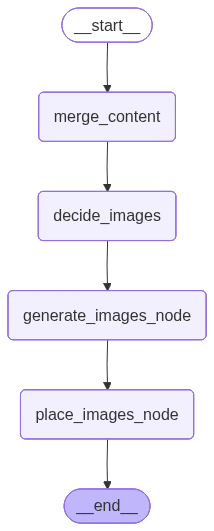

In [ ]:
sub_graph = StateGraph(BlogState)

sub_graph.add_node("merge_content", merge_content)
sub_graph.add_node("decide_images", decide_images)
sub_graph.add_node("generate_images_node", generate_images_node)
sub_graph.add_node("place_images_node", place_images_node)

sub_graph.add_edge(START, "merge_content")
sub_graph.add_edge("merge_content", "decide_images")
sub_graph.add_edge("decide_images", "generate_images_node")
sub_graph.add_edge("generate_images_node", "place_images_node")
sub_graph.add_edge("place_images_node", END)

sub_graph_workflow = sub_graph.compile()
sub_graph_workflow

# Graph

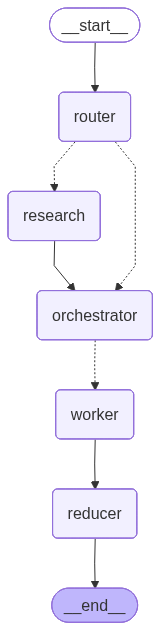

In [28]:
graph = StateGraph(BlogState)

graph.add_node("router", router_node)
graph.add_node("research", research_node)
graph.add_node("orchestrator", orchestrator)
graph.add_node("worker", worker_node)
graph.add_node("reducer", sub_graph_workflow)

graph.add_edge(START, "router")

graph.add_conditional_edges(
    "router",
    next_router,
    {"research": "research", "orchestrator": "orchestrator"}
)

graph.add_edge("research", "orchestrator")

graph.add_conditional_edges(
    "orchestrator",
    distribute_tasks,
    ["worker"]
)

graph.add_edge("worker", "reducer")
graph.add_edge("reducer", END)

workflow = graph.compile()
workflow

# Run Statement

In [29]:
from datetime import date

def run_statement(topic: str, as_of: Optional[str] = None):
# The date logic is bcz if user wants the blog to be written for a specific date.
    if as_of is None:
        as_of = date.today().isoformat()

    output = workflow.invoke(
        {
            "topic": topic,
            "require_research": False,
            "research_method": "open_book",
            "queries": [],
            "evidence": [],
            "plan": None,
            "sections": [],
            "merged_md": "",
            "md_with_placeholder": "",
            "image_specs": [],
            "final": "",
        }
    )

    return output

In [30]:
run_statement('Diff between Machine Learning & Agentic Ai.')

📊 Inserting 5 diagrams: ['[[IMAGE_1]]', '[[IMAGE_2]]', '[[IMAGE_3]]', '[[IMAGE_4]]', '[[IMAGE_5]]']
✅ Diagram generated for: [[IMAGE_1]]
✅ Diagram generated for: [[IMAGE_2]]
✅ Diagram generated for: [[IMAGE_3]]
✅ Diagram generated for: [[IMAGE_4]]
✅ Diagram generated for: [[IMAGE_5]]


{'topic': 'Diff between Machine Learning & Agentic Ai.',
 'research_method': 'hybrid',
 'require_research': True,
 'queries': ['machine learning vs agentic AI',
  'agentic AI applications in industry',
  'recent advancements in agentic AI research'],
 'evidence': [],
 'plan': Plan(blog_title='Unpacking the Distinctions: Machine Learning vs Agentic AI', audience='Technical professionals and enthusiasts interested in artificial intelligence', tone='Informative and analytical', tasks=[Task(id=1, title='Introduction to Machine Learning and Agentic AI', description='This section will introduce the fundamental concepts of Machine Learning and Agentic AI, setting the stage for a detailed comparison. It will cover the basic definitions, historical context, and current applications of both.', goal='The reader will understand the basic principles of Machine Learning and Agentic AI and how they are perceived in the context of artificial intelligence.', target_words=500, bullets=['Define Machine L